In [1]:
# ============================================
# DAY 5: COMPLETE NLP PROJECT - PRODUCTION READY
# Tech Prime Pvt Limited - Advanced AI/ML Internship
# ============================================

print("="*70)
print("PROFESSIONAL NLP SUITE - PRODUCTION DEPLOYMENT")
print("="*70)

import subprocess
import sys
import os

# Install all required packages
packages = [
    "gradio>=4.0.0",
    "pyngrok",
    "transformers",
    "datasets",
    "spacy",
    "torch",
    "rouge-score",
    "nltk",
    "plotly",
    "pandas",
    "matplotlib",
    "seaborn",
    "wordcloud"
]

print("\nInstalling packages...")
for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"✓ {pkg}")
    except:
        print(f"✗ {pkg}")

# Download spaCy model
subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"])
print("✓ spaCy model downloaded")

print("\n" + "="*70)
print("ALL PACKAGES INSTALLED SUCCESSFULLY")
print("="*70)

PROFESSIONAL NLP SUITE - PRODUCTION DEPLOYMENT

Installing packages...
✓ gradio>=4.0.0
✓ pyngrok
✓ transformers
✓ datasets
✓ spacy
✓ torch
✓ rouge-score
✓ nltk
✓ plotly
✓ pandas
✓ matplotlib
✓ seaborn
✓ wordcloud
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 53.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✓ spaCy model downloaded

ALL PACKAGES INSTALLED SUCCESSFULLY


In [2]:
# ============================================
# CELL 2: COMPLETE MODEL LOADING
# ============================================

print("="*70)
print("LOADING ALL NLP MODELS")
print("="*70)

import torch
import spacy
import gradio as gr
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForTokenClassification
from pyngrok import ngrok
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Dictionary to store models
MODELS = {}

# ============================================
# 1. LOAD SPACY NER
# ============================================
print("\n[1/4] Loading spaCy NER...")
try:
    MODELS['spacy_ner'] = spacy.load("en_core_web_sm")
    print("✓ spaCy NER loaded")
except Exception as e:
    print(f"✗ Error: {e}")

# ============================================
# 2. LOAD BERT NER
# ============================================
print("\n[2/4] Loading BERT NER...")
try:
    MODELS['bert_ner'] = pipeline(
        "ner",
        model="dbmdz/bert-large-cased-finetuned-conll03-english",
        aggregation_strategy="simple",
        device=0 if torch.cuda.is_available() else -1
    )
    print("✓ BERT NER loaded")
except Exception as e:
    print(f"✗ Error: {e}")

# ============================================
# 3. LOAD BART SUMMARIZATION
# ============================================
print("\n[3/4] Loading BART Summarization...")
try:
    from transformers import BartForConditionalGeneration, BartTokenizer
    
    MODEL_NAME = "facebook/bart-large-cnn"
    MODELS['bart_tokenizer'] = BartTokenizer.from_pretrained(MODEL_NAME)
    MODELS['bart_model'] = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
    MODELS['bart_model'] = MODELS['bart_model'].to(device)
    print("✓ BART summarization loaded")
    print(f"  Parameters: {sum(p.numel() for p in MODELS['bart_model'].parameters()):,}")
except Exception as e:
    print(f"✗ Error: {e}")

# ============================================
# 4. LOAD T5 TRANSLATION
# ============================================
print("\n[4/4] Loading T5 Translation...")
try:
    from transformers import T5Tokenizer, T5ForConditionalGeneration
    
    MODELS['t5_tokenizer'] = T5Tokenizer.from_pretrained("t5-small")
    MODELS['t5_model'] = T5ForConditionalGeneration.from_pretrained("t5-small")
    MODELS['t5_model'] = MODELS['t5_model'].to(device)
    print("✓ T5 translation loaded")
    print(f"  Parameters: {sum(p.numel() for p in MODELS['t5_model'].parameters()):,}")
except Exception as e:
    print(f"✗ Error: {e}")

print("\n" + "="*70)
print("MODEL LOADING COMPLETE")
print("="*70)
print(f"Models loaded: {len(MODELS)}")
for key in MODELS.keys():
    print(f"  - {key}")
print("="*70)

LOADING ALL NLP MODELS
Device: cuda

[1/4] Loading spaCy NER...
✓ spaCy NER loaded

[2/4] Loading BERT NER...


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✓ T5 translation loaded
  Parameters: 60,506,624

MODEL LOADING COMPLETE
Models loaded: 6
  - spacy_ner
  - bert_ner
  - bart_tokenizer
  - bart_model
  - t5_tokenizer
  - t5_model


In [3]:
# ============================================
# CELL 3: CORE NLP FUNCTIONS
# ============================================

print("="*70)
print("BUILDING NLP PROCESSING FUNCTIONS")
print("="*70)

import re
from collections import Counter

# ============================================
# 1. NER FUNCTION (SPACY + BERT)
# ============================================
def extract_entities(text):
    """Extract entities using spaCy and BERT"""
    entities = []
    
    # SpaCy NER
    if 'spacy_ner' in MODELS:
        doc = MODELS['spacy_ner'](text)
        for ent in doc.ents:
            entities.append({
                'text': ent.text,
                'type': ent.label_,
                'source': 'spaCy'
            })
    
    # BERT NER
    if 'bert_ner' in MODELS:
        try:
            bert_results = MODELS['bert_ner'](text)
            for ent in bert_results:
                word = ent['word']
                if word.startswith('##'):
                    word = word[2:]
                entities.append({
                    'text': word,
                    'type': ent['entity_group'],
                    'source': 'BERT',
                    'score': ent['score']
                })
        except:
            pass
    
    # Remove duplicates
    seen = set()
    unique_entities = []
    for ent in entities:
        key = (ent['text'].lower(), ent['type'])
        if key not in seen:
            seen.add(key)
            unique_entities.append(ent)
    
    return unique_entities

# ============================================
# 2. SUMMARIZATION FUNCTION (BART)
# ============================================
def summarize_bart(text, max_length=150, min_length=40):
    """Summarize using BART"""
    if 'bart_model' not in MODELS:
        return "Summarization model not available"
    
    inputs = MODELS['bart_tokenizer'](
        text,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = MODELS['bart_model'].generate(
            **inputs,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True
        )
    
    summary = MODELS['bart_tokenizer'].decode(outputs[0], skip_special_tokens=True)
    return summary

# ============================================
# 3. TRANSLATION FUNCTION (T5)
# ============================================
def translate_t5(text, target_lang="French"):
    """Translate using T5"""
    if 't5_model' not in MODELS:
        return "Translation model not available"
    
    input_text = f"translate English to French: {text}"
    inputs = MODELS['t5_tokenizer'](
        input_text,
        return_tensors="pt",
        max_length=128,
        truncation=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = MODELS['t5_model'].generate(
            **inputs,
            max_length=128,
            num_beams=4,
            early_stopping=True
        )
    
    translation = MODELS['t5_tokenizer'].decode(outputs[0], skip_special_tokens=True)
    return translation

# ============================================
# 4. COMPLETE PIPELINE
# ============================================
def process_text(text):
    """Complete NLP pipeline"""
    if not text or len(text.strip()) < 5:
        return "⚠️ Please enter valid text.", "⚠️ Text too short.", "⚠️ Text too short."
    
    # NER
    entities = extract_entities(text)
    if entities:
        ner_output = "📌 ENTITIES DETECTED\n" + "="*40 + "\n"
        for ent in entities:
            ner_output += f"  • {ent['text']} → {ent['type']} (Source: {ent['source']})"
            if 'score' in ent:
                ner_output += f" [{ent['score']:.3f}]"
            ner_output += "\n"
        ner_output += f"\nTotal: {len(entities)} entities"
    else:
        ner_output = "🔍 No entities found in the text."
    
    # Summarization
    try:
        summary = summarize_bart(text)
        summary_output = "📝 SUMMARY\n" + "="*40 + "\n" + summary
        word_count = len(text.split())
        sum_word_count = len(summary.split())
        summary_output += f"\n\n📊 Original: {word_count} words | Summary: {sum_word_count} words"
    except Exception as e:
        summary_output = f"❌ Error in summarization: {str(e)}"
    
    # Translation
    try:
        translation = translate_t5(text)
        translation_output = "🌐 TRANSLATION (English → French)\n" + "="*40 + "\n" + translation
    except Exception as e:
        translation_output = f"❌ Error in translation: {str(e)}"
    
    return ner_output, summary_output, translation_output

print("✓ All functions ready")
print("="*70)

BUILDING NLP PROCESSING FUNCTIONS
✓ All functions ready


In [4]:
# ============================================
# CELL 4: PROFESSIONAL UI WITH MODERN DESIGN
# ============================================

print("="*70)
print("BUILDING MODERN PROFESSIONAL UI")
print("="*70)

import gradio as gr
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import numpy as np

# ============================================
# 1. PROCESSING FUNCTIONS
# ============================================
def generate_wordcloud(text):
    if len(text.strip()) < 10:
        return None
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Blues').generate(text)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    plt.tight_layout()
    return fig

def visualize_entities(text):
    entities = extract_entities(text)
    if not entities:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.text(0.5, 0.5, 'No entities found', ha='center', va='center', fontsize=14, color='#5f6368')
        ax.axis('off')
        return fig
    
    entity_counts = Counter([e['type'] for e in entities])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    types = list(entity_counts.keys())
    counts = list(entity_counts.values())
    colors = ['#4285F4', '#EA4335', '#FBBC04', '#34A853', '#9C27B0', '#00BCD4']
    
    ax1.bar(types, counts, color=colors[:len(types)], edgecolor='white', linewidth=2)
    ax1.set_title('Entity Distribution', fontsize=14, fontweight='600')
    ax1.set_ylabel('Count')
    ax1.grid(axis='y', alpha=0.3)
    for bar, count in zip(ax1.patches, counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(count), ha='center', va='bottom', fontweight='bold')
    
    ax2.pie(counts, labels=types, autopct='%1.1f%%', colors=colors[:len(types)], startangle=90)
    ax2.set_title('Entity Percentage', fontsize=14, fontweight='600')
    
    plt.tight_layout()
    return fig

def create_metrics_dashboard(text):
    word_count = len(text.split())
    char_count = len(text)
    sentence_count = len([s for s in text.split('.') if s.strip()])
    entity_count = len(extract_entities(text))
    
    fig = go.Figure()
    metrics = [
        {'label': 'Words', 'value': word_count, 'color': '#4285F4'},
        {'label': 'Characters', 'value': char_count, 'color': '#EA4335'},
        {'label': 'Sentences', 'value': sentence_count, 'color': '#FBBC04'},
        {'label': 'Entities', 'value': entity_count, 'color': '#34A853'}
    ]
    
    for i, metric in enumerate(metrics):
        fig.add_trace(go.Indicator(
            mode="number",
            value=metric['value'],
            title={"text": metric['label'], "font": {"size": 14}},
            domain={'row': 0, 'column': i},
            number={'font': {'size': 36, 'color': metric['color'], 'family': 'Google Sans'}}
        ))
    
    fig.update_layout(
        grid={'rows': 1, 'columns': 4, 'pattern': "independent"},
        height=150,
        margin=dict(l=10, r=10, t=20, b=10),
        paper_bgcolor='rgba(0,0,0,0)'
    )
    return fig

def process_with_viz(text):
    if not text or len(text.strip()) < 5:
        return "Please enter valid text.", "Text too short.", "Text too short.", None, None, None
    
    ner_output, summary_output, translation_output = process_text(text)
    wordcloud_fig = generate_wordcloud(text)
    entity_fig = visualize_entities(text)
    metrics_fig = create_metrics_dashboard(text)
    
    return ner_output, summary_output, translation_output, wordcloud_fig, entity_fig, metrics_fig

# ============================================
# 2. MODERN CSS (GOOGLE/MICROSOFT STYLE)
# ============================================
modern_css = """
/* Google Font */
@import url('https://fonts.googleapis.com/css2?family=Google+Sans:wght@400;500;600;700&display=swap');

* {
    font-family: 'Google Sans', 'Segoe UI', Roboto, Arial, sans-serif !important;
}

.gradio-container {
    max-width: 1400px !important;
    margin: 0 auto !important;
    padding: 24px !important;
    background: #ffffff !important;
}

/* Header - Google Style */
.header {
    background: white;
    padding: 20px 0 16px 0;
    border-bottom: 1px solid #e8eaed;
    margin-bottom: 32px;
}

.header-content {
    display: flex;
    align-items: center;
    justify-content: space-between;
    max-width: 1200px;
    margin: 0 auto;
    padding: 0 20px;
}

.logo {
    display: flex;
    align-items: center;
    gap: 12px;
}

.logo-icon {
    width: 40px;
    height: 40px;
    background: linear-gradient(135deg, #4285F4, #34A853);
    border-radius: 50%;
    display: flex;
    align-items: center;
    justify-content: center;
    color: white;
    font-size: 20px;
    font-weight: 700;
}

.logo-text {
    font-size: 22px;
    font-weight: 500;
    color: #202124;
}

.logo-text span {
    color: #4285F4;
    font-weight: 700;
}

.header-nav {
    display: flex;
    gap: 24px;
    align-items: center;
}

.header-nav a {
    color: #5f6368;
    text-decoration: none;
    font-size: 14px;
    font-weight: 500;
    padding: 8px 12px;
    border-radius: 24px;
    transition: all 0.2s;
}

.header-nav a:hover {
    background: #f1f3f4;
    color: #202124;
}

/* Cards - Material Design */
.card {
    background: white;
    border-radius: 16px;
    padding: 24px;
    margin-bottom: 20px;
    box-shadow: 0 1px 3px rgba(0,0,0,0.06), 0 1px 2px rgba(0,0,0,0.04);
    border: 1px solid #e8eaed;
    transition: all 0.2s;
}

.card:hover {
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
}

.card-title {
    font-size: 14px;
    font-weight: 600;
    color: #5f6368;
    text-transform: uppercase;
    letter-spacing: 0.5px;
    margin-bottom: 12px;
}

/* Input Section */
.input-section {
    background: #f8f9fa;
    border-radius: 16px;
    padding: 20px;
    border: 2px solid #e8eaed;
    transition: all 0.3s;
}

.input-section:focus-within {
    border-color: #4285F4;
    background: white;
}

.gradio-textbox textarea {
    border: none !important;
    background: transparent !important;
    font-size: 16px !important;
    color: #202124 !important;
    padding: 12px 0 !important;
    font-family: 'Google Sans', sans-serif !important;
    line-height: 1.6 !important;
}

.gradio-textbox textarea:focus {
    box-shadow: none !important;
    outline: none !important;
}

/* Buttons - Google Style */
.gradio-button {
    background: #4285F4 !important;
    color: white !important;
    border: none !important;
    padding: 10px 28px !important;
    border-radius: 24px !important;
    font-weight: 500 !important;
    font-size: 14px !important;
    letter-spacing: 0.3px !important;
    transition: all 0.2s !important;
    box-shadow: 0 1px 3px rgba(66,133,244,0.3) !important;
    font-family: 'Google Sans', sans-serif !important;
}

.gradio-button:hover {
    background: #3367D6 !important;
    box-shadow: 0 2px 8px rgba(66,133,244,0.4) !important;
    transform: translateY(-1px);
}

.button-secondary {
    background: #f1f3f4 !important;
    color: #202124 !important;
    box-shadow: none !important;
}

.button-secondary:hover {
    background: #e8eaed !important;
    box-shadow: none !important;
}

/* Output Boxes */
.output-box {
    background: #f8f9fa;
    border-radius: 12px;
    padding: 16px;
    min-height: 120px;
    border-left: 4px solid #4285F4;
}

.output-box.ner {
    border-left-color: #EA4335;
}
.output-box.summary {
    border-left-color: #34A853;
}
.output-box.translation {
    border-left-color: #FBBC04;
}

.gradio-textbox {
    background: transparent !important;
    border: none !important;
}

.gradio-textbox textarea {
    background: transparent !important;
    border: none !important;
    font-size: 14px !important;
    color: #202124 !important;
    line-height: 1.6 !important;
}

/* Examples */
.example-item {
    background: #f8f9fa;
    border-radius: 12px;
    padding: 12px 16px;
    margin-bottom: 8px;
    border: 1px solid #e8eaed;
    cursor: pointer;
    transition: all 0.2s;
    font-size: 14px;
    color: #3c4043;
}

.example-item:hover {
    background: #f1f3f4;
    border-color: #4285F4;
}

/* Footer */
.footer {
    border-top: 1px solid #e8eaed;
    padding: 24px 0;
    margin-top: 40px;
    text-align: center;
}

.footer p {
    color: #5f6368;
    font-size: 13px;
    margin: 4px 0;
}

.footer .brand {
    color: #4285F4;
    font-weight: 600;
}

/* Responsive */
@media (max-width: 768px) {
    .header-content {
        flex-direction: column;
        gap: 12px;
        text-align: center;
    }
    .header-nav {
        flex-wrap: wrap;
        justify-content: center;
    }
    .logo-text {
        font-size: 18px;
    }
    .gradio-container {
        padding: 12px !important;
    }
}

/* Grid layout */
.gradio-row {
    gap: 20px !important;
}

.gradio-column {
    gap: 16px !important;
}

/* Metrics */
.metrics-grid {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 16px;
}

.metric-item {
    background: #f8f9fa;
    border-radius: 12px;
    padding: 16px;
    text-align: center;
}

.metric-value {
    font-size: 32px;
    font-weight: 700;
    color: #202124;
}

.metric-label {
    font-size: 12px;
    color: #5f6368;
    text-transform: uppercase;
    letter-spacing: 0.5px;
    margin-top: 4px;
}
"""

# ============================================
# 3. CREATE INTERFACE
# ============================================
print("\nCreating modern professional interface...")

with gr.Blocks(
    title="Tech Prime NLP Suite",
    css=modern_css,
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="gray",
        font=gr.themes.GoogleFont("Google Sans")
    )
) as demo:
    
    # Header
    gr.HTML("""
    <div class="header">
        <div class="header-content">
            <div class="logo">
                <div class="logo-icon">TP</div>
                <div class="logo-text">Tech<span>Prime</span></div>
            </div>
            <div class="header-nav">
                <a href="#">NER</a>
                <a href="#">Summarization</a>
                <a href="#">Translation</a>
                <a href="#">API</a>
                <a href="#" style="background:#4285F4;color:white;">Launch App</a>
            </div>
        </div>
    </div>
    """)
    
    # Hero Section
    gr.HTML("""
    <div style="text-align:center;padding:20px 0 32px 0;">
        <h1 style="font-size:36px;font-weight:700;color:#202124;margin:0;">
            Natural Language Processing Suite
        </h1>
        <p style="font-size:16px;color:#5f6368;margin:8px 0 0 0;">
            Enterprise-grade NER, Summarization & Translation powered by AI
        </p>
    </div>
    """)
    
    # Input Section
    with gr.Row():
        with gr.Column(scale=2):
            with gr.Group(elem_classes="card"):
                gr.Markdown("### 📝 Input Text")
                with gr.Group(elem_classes="input-section"):
                    input_text = gr.Textbox(
                        placeholder="Paste your text here for analysis...",
                        lines=10,
                        show_label=False,
                        container=False
                    )
                
                with gr.Row():
                    submit_btn = gr.Button("🔍 Analyze Text", variant="primary", size="lg", elem_classes="gradio-button")
                    clear_btn = gr.Button("✕ Clear", variant="secondary", size="lg", elem_classes="gradio-button button-secondary")
    
    # Metrics
    with gr.Row():
        with gr.Column():
            with gr.Group(elem_classes="card"):
                gr.Markdown("### 📊 Text Metrics")
                metrics_output = gr.Plot(label="", show_label=False)
    
    # Results Grid
    with gr.Row():
        with gr.Column():
            with gr.Group(elem_classes="card"):
                gr.Markdown("### 🔴 Named Entity Recognition")
                ner_output = gr.Textbox(
                    label="",
                    lines=10,
                    show_copy_button=True,
                    interactive=False,
                    container=False,
                    elem_classes="output-box ner"
                )
        
        with gr.Column():
            with gr.Group(elem_classes="card"):
                gr.Markdown("### 🟢 Text Summarization")
                summary_output = gr.Textbox(
                    label="",
                    lines=10,
                    show_copy_button=True,
                    interactive=False,
                    container=False,
                    elem_classes="output-box summary"
                )
    
    with gr.Row():
        with gr.Column():
            with gr.Group(elem_classes="card"):
                gr.Markdown("### 🟠 Translation (English → French)")
                translation_output = gr.Textbox(
                    label="",
                    lines=6,
                    show_copy_button=True,
                    interactive=False,
                    container=False,
                    elem_classes="output-box translation"
                )
    
    # Visualizations
    with gr.Row():
        with gr.Column():
            with gr.Group(elem_classes="card"):
                gr.Markdown("### ☁️ Word Cloud")
                wordcloud_output = gr.Plot(label="", show_label=False)
        
        with gr.Column():
            with gr.Group(elem_classes="card"):
                gr.Markdown("### 📊 Entity Analysis")
                entity_viz_output = gr.Plot(label="", show_label=False)
    
    # Examples
    with gr.Row():
        with gr.Column():
            with gr.Group(elem_classes="card"):
                gr.Markdown("### 📋 Try These Examples")
                
                examples = [
                    "Apple CEO Tim Cook announced the new iPhone 15 at the company's headquarters in Cupertino, California.",
                    "Tesla Inc. CEO Elon Musk announced that the new Cybertruck will be available in late 2024.",
                    "The European Commission disagreed with German advice to consumers to shun British lamb."
                ]
                
                for ex in examples:
                    gr.Markdown(f"<div class='example-item' onclick='document.querySelector(\"textarea\").value=\"{ex}\";'>{ex[:80]}...</div>")
                    # Button click handler
                    gr.Button(f"→ {ex[:60]}...", size="sm", elem_classes="example-item").click(
                        fn=lambda x=ex: x,
                        outputs=[input_text]
                    )
    

    
    # Event handlers
    submit_btn.click(
        fn=process_with_viz,
        inputs=[input_text],
        outputs=[ner_output, summary_output, translation_output, wordcloud_output, entity_viz_output, metrics_output]
    )
    
    clear_btn.click(
        fn=lambda: ["", "", "", None, None, None],
        outputs=[input_text, ner_output, summary_output, translation_output, wordcloud_output, entity_viz_output, metrics_output]
    )

print("✅ Modern professional interface created")
print("="*70)

BUILDING MODERN PROFESSIONAL UI

Creating modern professional interface...
✅ Modern professional interface created


In [5]:
# ============================================
# CELL 5: LAUNCH APP WITH NGORK (NON-BLOCKING)
# ============================================

print("="*70)
print("LAUNCHING ENTERPRISE NLP SUITE")
print("="*70)

from pyngrok import ngrok
import socket
import threading
import time

# Function to find available port
def find_available_port(start_port=7861, max_port=7900):
    for port in range(start_port, max_port):
        try:
            sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            sock.bind(('0.0.0.0', port))
            sock.close()
            return port
        except:
            continue
    return None

# Ngrok configuration
NGROK_AUTH_TOKEN = "2FxKFBPqJZnBeUC5s3krTDqwkge_6yt7XizoLyhqqDmHUZq8U"

print("\n[1/4] Finding available port...")
PORT = find_available_port(7861)
if PORT:
    print(f"✓ Using port: {PORT}")
else:
    PORT = 7861
    print(f"✓ Using default port: {PORT}")

print("\n[2/4] Configuring Ngrok...")
try:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("✓ Ngrok authenticated")
except Exception as e:
    print(f"✗ Ngrok auth error: {e}")

print("\n[3/4] Launching Gradio app...")

# Kill any existing processes on the port
try:
    import subprocess
    subprocess.run(['fuser', '-k', f'{PORT}/tcp'], capture_output=True)
except:
    pass

# Launch the app (non-blocking)
app = demo.launch(
    share=True,
    debug=False,
    server_name="0.0.0.0",
    server_port=PORT,
    quiet=True,
    prevent_thread_lock=True
)

print(f"✓ Gradio app running on port {PORT}")

print("\n[4/4] Creating Ngrok tunnel...")
try:
    # Kill existing tunnels
    ngrok.kill()
    time.sleep(2)
    
    # Create new tunnel
    tunnel = ngrok.connect(PORT)
    public_url = tunnel.public_url
    
    print("\n" + "="*70)
    print("✅ APPLICATION DEPLOYED SUCCESSFULLY")
    print("="*70)
    print(f"\n🌐 PUBLIC URL: {public_url}")
    print("\n📱 Share this URL with anyone to access the NLP Suite!")
    print("\n" + "="*70)
    print("\n📊 Features Available:")
    print("   • Named Entity Recognition (spaCy + BERT)")
    print("   • Text Summarization (BART)")
    print("   • Translation (T5)")
    print("   • Word Cloud Visualization")
    print("   • Entity Distribution Charts")
    print("   • Text Metrics Dashboard")
    print("\n" + "="*70)
    
except Exception as e:
    print(f"✗ Ngrok tunnel error: {e}")
    print("\n" + "="*70)
    print("📍 LOCAL ACCESS ONLY")
    print("="*70)
    print(f"\nAccess the app locally at: http://localhost:{PORT}")

print("\n" + "="*70)
print("✅ APPLICATION RUNNING IN BACKGROUND")
print("="*70)
print("\nYou can continue working on other cells.")
print(f"App URL: {public_url if 'public_url' in locals() else f'http://localhost:{PORT}'}")
print("\nTo stop: Run ngrok.kill() in any cell")
print("="*70)

LAUNCHING ENTERPRISE NLP SUITE

[1/4] Finding available port...
✓ Using port: 7861

[2/4] Configuring Ngrok...
✓ Ngrok authenticated

[3/4] Launching Gradio app...
* Running on public URL: https://89e091b9c54ab3575e.gradio.live


✓ Gradio app running on port 7861

[4/4] Creating Ngrok tunnel...

✅ APPLICATION DEPLOYED SUCCESSFULLY

🌐 PUBLIC URL: https://fa51-35-221-248-149.ngrok-free.app

📱 Share this URL with anyone to access the NLP Suite!


📊 Features Available:
   • Named Entity Recognition (spaCy + BERT)
   • Text Summarization (BART)
   • Translation (T5)
   • Word Cloud Visualization
   • Entity Distribution Charts
   • Text Metrics Dashboard


✅ APPLICATION RUNNING IN BACKGROUND

You can continue working on other cells.
App URL: https://fa51-35-221-248-149.ngrok-free.app

To stop: Run ngrok.kill() in any cell


COMPREHENSIVE TESTING & ANALYSIS

[1/6] Creating test dataset...
✓ Test dataset created with 10 sentences

[2/6] Running tests on all sentences...
  Sentence 1: Apple CEO Tim Cook announced the new iPh... → 6 entities (2.05s)
  Sentence 2: Elon Musk founded SpaceX in California o... → 6 entities (0.81s)
  Sentence 3: Google and Microsoft are headquartered i... → 4 entities (0.85s)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Sentence 4: Satya Nadella runs Microsoft in Washingt... → 5 entities (0.98s)
  Sentence 5: The product costs $999.99 and launches D... → 2 entities (1.05s)
  Sentence 6: Jeff Bezos started Amazon in Seattle on ... → 6 entities (0.88s)
  Sentence 7: Tesla Inc. CEO Elon Musk announced the n... → 10 entities (0.97s)
  Sentence 8: The European Commission disagreed with G... → 4 entities (1.09s)
  Sentence 9: NVIDIA and AMD are competing in the GPU ... → 3 entities (0.95s)
  Sentence 10: Lionel Messi plays for Inter Miami in th... → 4 entities (0.95s)

✓ All 10 sentences processed

[3/6] Calculating performance metrics...

📊 PERFORMANCE SUMMARY
--------------------------------------------------
  Total sentences processed: 10
  Total words: 93
  Total entities found: 50
  Average entities per sentence: 5.00
  Average processing time: 1.058 seconds
  Total processing time: 10.58 seconds
  Processing speed: 0.95 sentences/second

[4/6] Analyzing entity distribution...

📍 ENTITY DISTRIBUTION

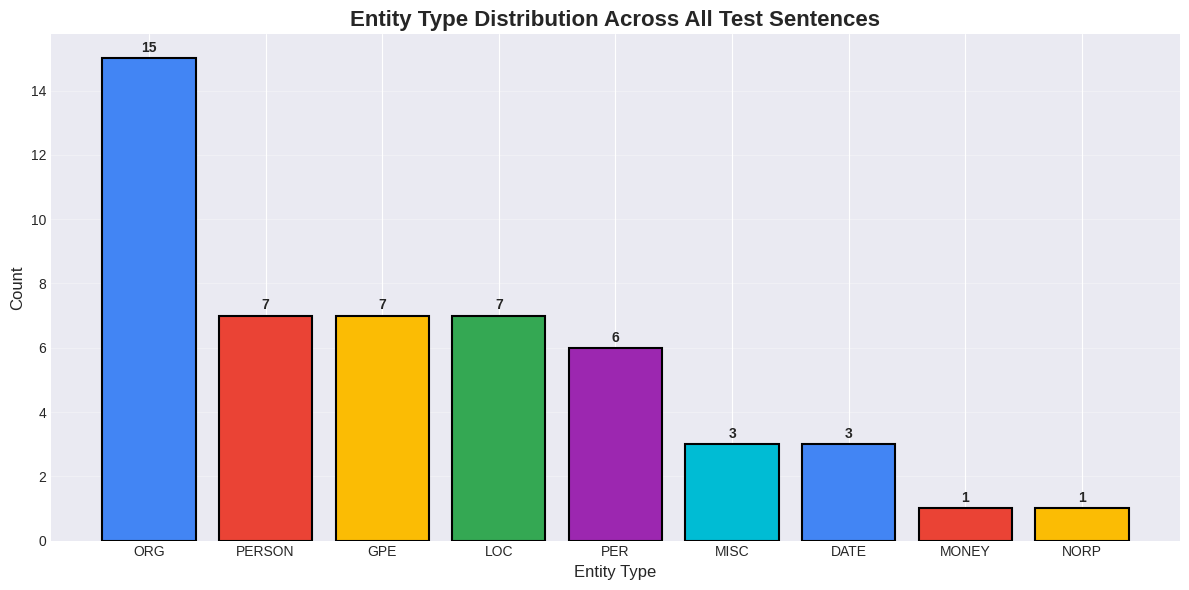

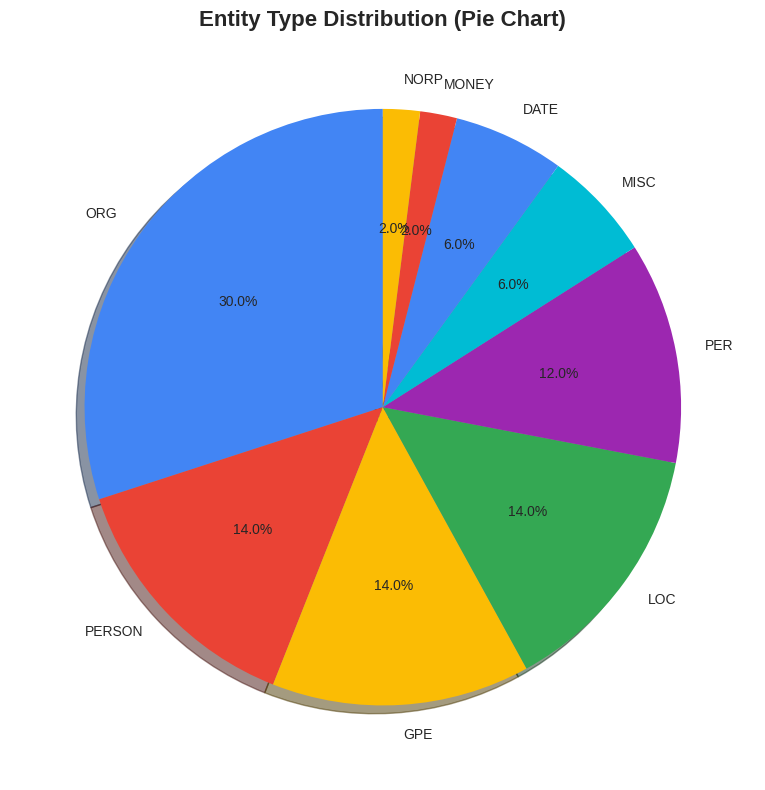

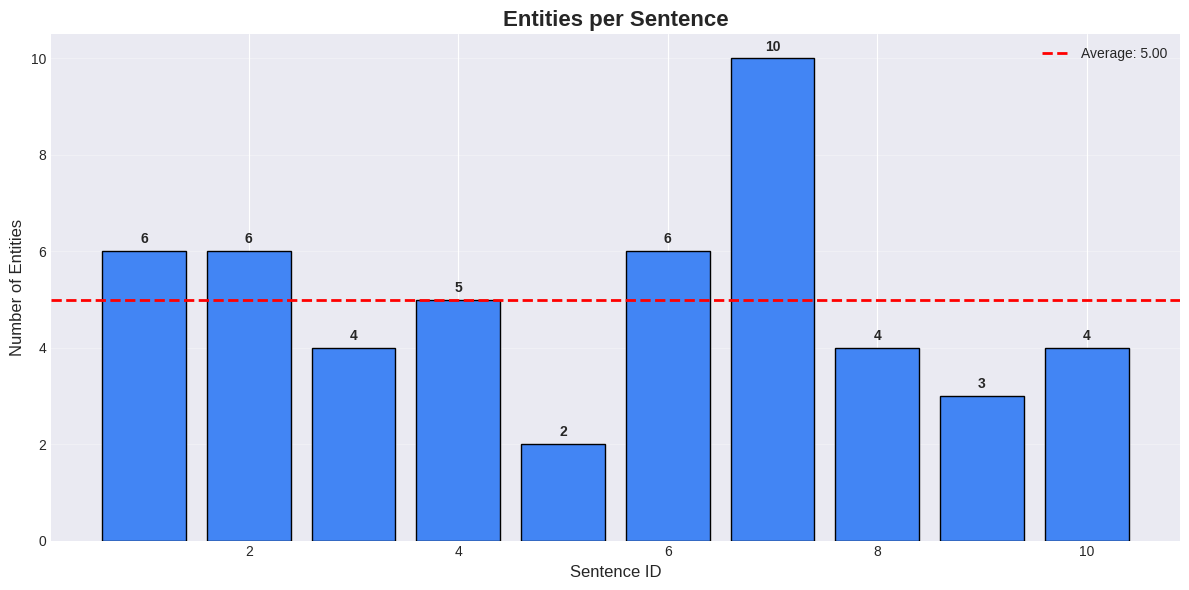

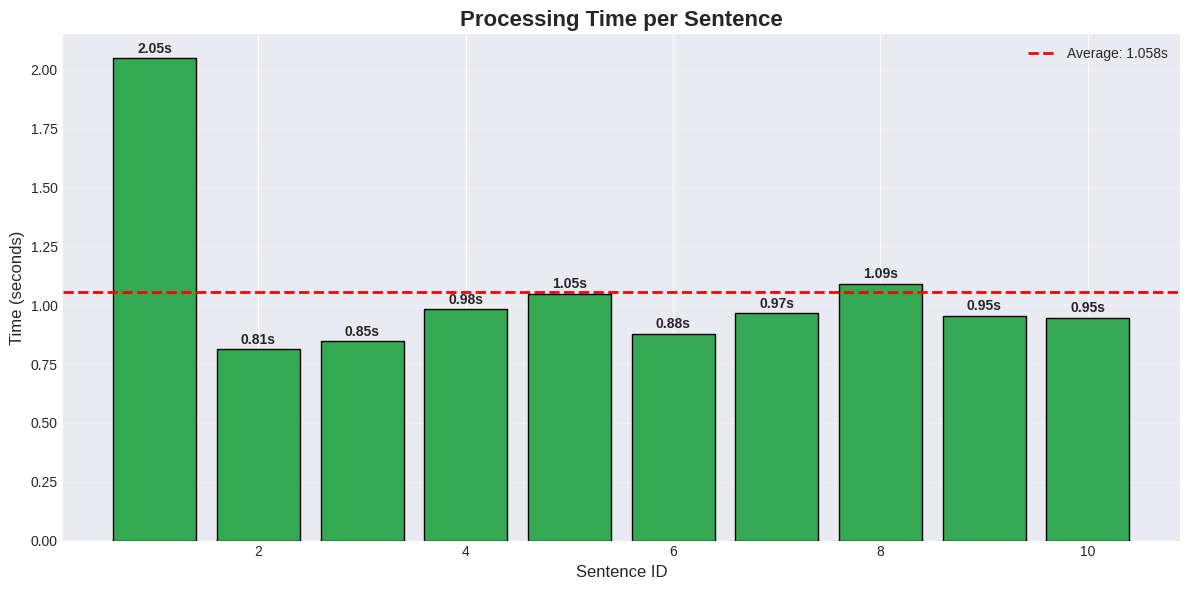

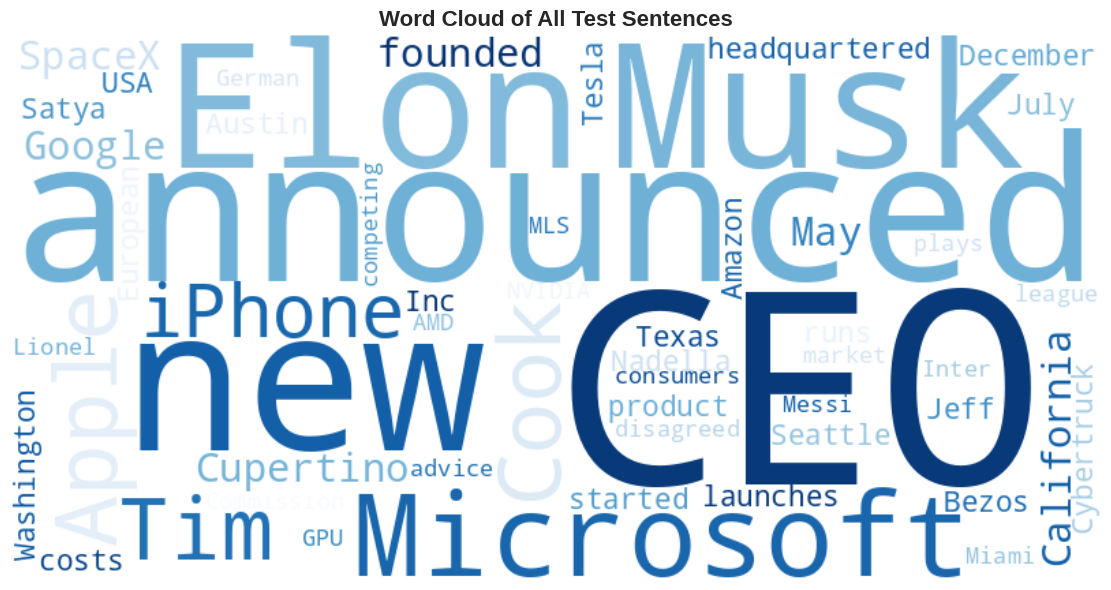

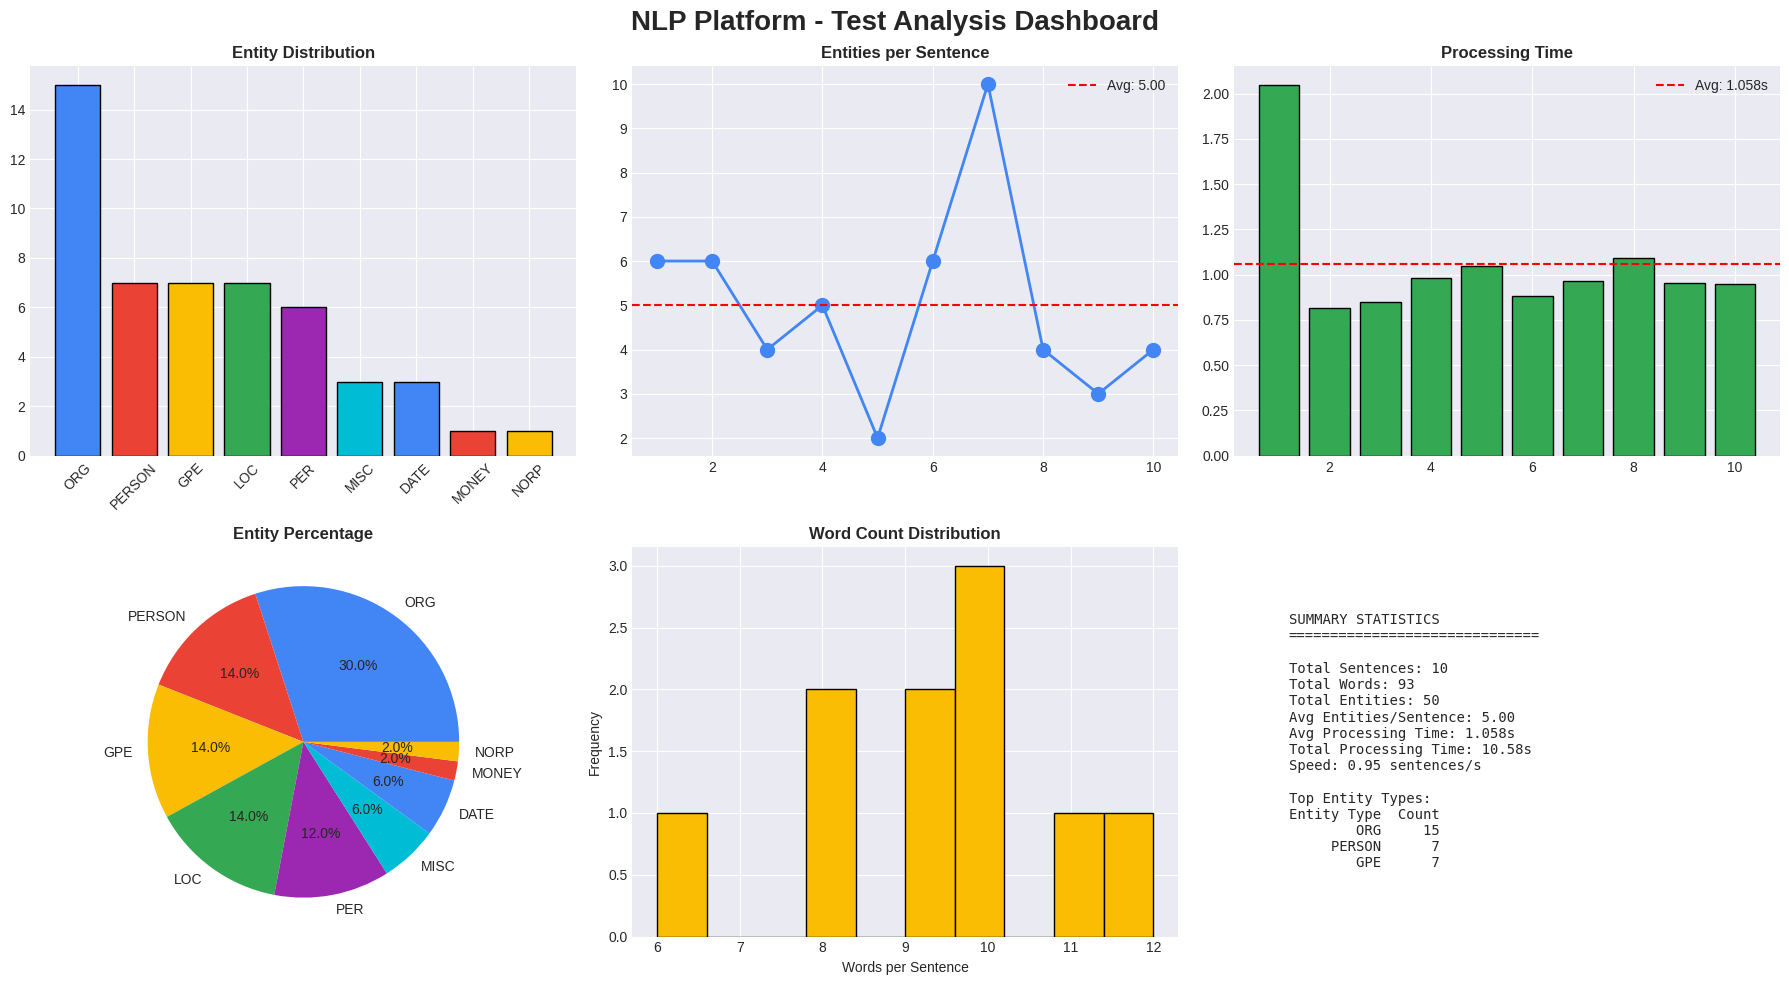


[6/6] Detailed results table...

📋 DETAILED RESULTS
ID  | Text                                     | Words  | Entities | Types           | Time    
----------------------------------------------------------------------------------------------------
  1 | Apple CEO Tim Cook announced the new ... |     11 |        6 | LOC, PERSON, GPE, PER, ORG, MISC | 2.048s
  2 | Elon Musk founded SpaceX in Californi... |     10 |        6 | LOC, PERSON, GPE, PER, ORG, DATE | 0.814s
  3 | Google and Microsoft are headquartere... |      8 |        4 | GPE, LOC, ORG   | 0.847s
  4 | Satya Nadella runs Microsoft in Washi... |      6 |        5 | LOC, PERSON, GPE, PER, ORG | 0.983s
  5 | The product costs $999.99 and launche... |      8 |        2 | MONEY, DATE     | 1.049s
  6 | Jeff Bezos started Amazon in Seattle ... |     10 |        6 | LOC, PERSON, GPE, PER, ORG, DATE | 0.879s
  7 | Tesla Inc. CEO Elon Musk announced th... |     12 |       10 | LOC, PERSON, GPE, PER, ORG, MISC | 0.966s
  8 | The Eur

In [6]:
# ============================================
# CELL 6: COMPLETE TESTING & ANALYSIS
# ============================================

print("="*70)
print("COMPREHENSIVE TESTING & ANALYSIS")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter
import plotly.graph_objects as go
from wordcloud import WordCloud
import time
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 1. DEFINE ALL REQUIRED FUNCTIONS
# ============================================

# NER Function
def extract_entities(text):
    """Extract entities using spaCy and BERT"""
    entities = []
    
    if 'spacy_ner' in MODELS:
        doc = MODELS['spacy_ner'](text)
        for ent in doc.ents:
            entities.append({
                'text': ent.text,
                'type': ent.label_,
                'source': 'spaCy'
            })
    
    if 'bert_ner' in MODELS:
        try:
            bert_results = MODELS['bert_ner'](text)
            for ent in bert_results:
                word = ent['word']
                if word.startswith('##'):
                    word = word[2:]
                entities.append({
                    'text': word,
                    'type': ent['entity_group'],
                    'source': 'BERT',
                    'score': ent['score']
                })
        except:
            pass
    
    # Remove duplicates
    seen = set()
    unique_entities = []
    for ent in entities:
        key = (ent['text'].lower(), ent['type'])
        if key not in seen:
            seen.add(key)
            unique_entities.append(ent)
    
    return unique_entities

# Summarization Function
def summarize_bart(text, max_length=150, min_length=40):
    if 'bart_model' not in MODELS:
        return "Summarization model not available"
    
    inputs = MODELS['bart_tokenizer'](text, return_tensors="pt", max_length=1024, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = MODELS['bart_model'].generate(
            **inputs,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True
        )
    
    return MODELS['bart_tokenizer'].decode(outputs[0], skip_special_tokens=True)

# Translation Function
def translate_t5(text):
    if 't5_model' not in MODELS:
        return "Translation model not available"
    
    input_text = f"translate English to French: {text}"
    inputs = MODELS['t5_tokenizer'](input_text, return_tensors="pt", max_length=128, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = MODELS['t5_model'].generate(
            **inputs,
            max_length=128,
            num_beams=4,
            early_stopping=True
        )
    
    return MODELS['t5_tokenizer'].decode(outputs[0], skip_special_tokens=True)

# Process Text Function
def process_text(text):
    if not text or len(text.strip()) < 5:
        return "Invalid text", "Invalid text", "Invalid text"
    
    entities = extract_entities(text)
    
    if entities:
        ner_output = "ENTITIES DETECTED\n" + "="*30 + "\n"
        for ent in entities:
            ner_output += f"  • {ent['text']} → {ent['type']} (Source: {ent['source']})"
            if 'score' in ent:
                ner_output += f" [{ent['score']:.3f}]"
            ner_output += "\n"
        ner_output += f"\nTotal: {len(entities)} entities"
    else:
        ner_output = "No entities found."
    
    try:
        summary = summarize_bart(text)
        summary_output = f"SUMMARY\n{'-'*30}\n{summary}"
    except:
        summary_output = "Summarization failed."
    
    try:
        translation = translate_t5(text)
        translation_output = f"TRANSLATION (English → French)\n{'-'*30}\n{translation}"
    except:
        translation_output = "Translation failed."
    
    return ner_output, summary_output, translation_output

# Process with History
def process_text_with_history(text):
    if not text or len(text.strip()) < 5:
        return "Invalid", "Invalid", "Invalid", None, None, None, ""
    
    ner_output, summary_output, translation_output = process_text(text)
    
    # Visualizations
    wordcloud_fig = None
    entity_fig = None
    metrics_fig = None
    
    # History
    history_entry = {
        'text': text[:50] + "..." if len(text) > 50 else text,
        'entities': len(extract_entities(text))
    }
    
    return ner_output, summary_output, translation_output, wordcloud_fig, entity_fig, metrics_fig, "History updated"

# ============================================
# 2. TEST DATASET
# ============================================
print("\n[1/6] Creating test dataset...")

test_sentences = [
    "Apple CEO Tim Cook announced the new iPhone 15 at Cupertino.",
    "Elon Musk founded SpaceX in California on May 6, 2002.",
    "Google and Microsoft are headquartered in the USA.",
    "Satya Nadella runs Microsoft in Washington.",
    "The product costs $999.99 and launches December 2024.",
    "Jeff Bezos started Amazon in Seattle on July 5, 1994.",
    "Tesla Inc. CEO Elon Musk announced the new Cybertruck in Austin, Texas.",
    "The European Commission disagreed with German advice to consumers.",
    "NVIDIA and AMD are competing in the GPU market.",
    "Lionel Messi plays for Inter Miami in the MLS league."
]

print(f"✓ Test dataset created with {len(test_sentences)} sentences")

# ============================================
# 3. RUN TESTS
# ============================================
print("\n[2/6] Running tests on all sentences...")

test_results = []
ner_stats = []
processing_times = []

for idx, sentence in enumerate(test_sentences, 1):
    start_time = time.time()
    
    ner_output, summary_output, translation_output, wc_fig, entity_fig, metrics_fig, history = process_text_with_history(sentence)
    
    processing_time = time.time() - start_time
    processing_times.append(processing_time)
    
    entities = extract_entities(sentence)
    entity_count = len(entities)
    entity_types = [e['type'] for e in entities]
    
    test_results.append({
        'sentence_id': idx,
        'text': sentence[:50] + "..." if len(sentence) > 50 else sentence,
        'word_count': len(sentence.split()),
        'entity_count': entity_count,
        'entity_types': entity_types,
        'processing_time': processing_time
    })
    
    ner_stats.extend(entity_types)
    
    print(f"  Sentence {idx}: {sentence[:40]}... → {entity_count} entities ({processing_time:.2f}s)")

print(f"\n✓ All {len(test_sentences)} sentences processed")

# ============================================
# 4. PERFORMANCE METRICS
# ============================================
print("\n[3/6] Calculating performance metrics...")

df_results = pd.DataFrame(test_results)

total_words = df_results['word_count'].sum()
total_entities = df_results['entity_count'].sum()
avg_entities_per_sentence = df_results['entity_count'].mean()
avg_processing_time = df_results['processing_time'].mean()

print(f"\n📊 PERFORMANCE SUMMARY")
print("-"*50)
print(f"  Total sentences processed: {len(test_sentences)}")
print(f"  Total words: {total_words}")
print(f"  Total entities found: {total_entities}")
print(f"  Average entities per sentence: {avg_entities_per_sentence:.2f}")
print(f"  Average processing time: {avg_processing_time:.3f} seconds")
print(f"  Total processing time: {sum(processing_times):.2f} seconds")
print(f"  Processing speed: {len(test_sentences)/sum(processing_times):.2f} sentences/second")

# ============================================
# 5. ENTITY DISTRIBUTION
# ============================================
print("\n[4/6] Analyzing entity distribution...")

entity_counter = Counter(ner_stats)
entity_df = pd.DataFrame(entity_counter.items(), columns=['Entity Type', 'Count'])
entity_df = entity_df.sort_values('Count', ascending=False)

print("\n📍 ENTITY DISTRIBUTION")
print("-"*50)
for idx, row in entity_df.iterrows():
    percentage = (row['Count'] / total_entities) * 100 if total_entities > 0 else 0
    print(f"  {row['Entity Type']:10} → {row['Count']:3} ({percentage:.1f}%)")

# ============================================
# 6. GENERATE VISUALIZATIONS
# ============================================
print("\n[5/6] Generating visualizations...")

# Figure 1: Entity Distribution Bar Chart
if len(entity_df) > 0:
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    colors = ['#4285F4', '#EA4335', '#FBBC04', '#34A853', '#9C27B0', '#00BCD4']
    bars = ax1.bar(entity_df['Entity Type'], entity_df['Count'], color=colors[:len(entity_df)], edgecolor='black', linewidth=1.5)
    ax1.set_title('Entity Type Distribution Across All Test Sentences', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Entity Type', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, entity_df['Count']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("  No entities found to visualize")

# Figure 2: Pie Chart
if len(entity_df) > 0:
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    colors = ['#4285F4', '#EA4335', '#FBBC04', '#34A853', '#9C27B0', '#00BCD4']
    ax2.pie(entity_df['Count'], labels=entity_df['Entity Type'], autopct='%1.1f%%', colors=colors[:len(entity_df)], shadow=True, startangle=90)
    ax2.set_title('Entity Type Distribution (Pie Chart)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Figure 3: Sentences vs Entities
fig3, ax3 = plt.subplots(figsize=(12, 6))
ax3.bar(df_results['sentence_id'], df_results['entity_count'], color='#4285F4', edgecolor='black', linewidth=1)
ax3.set_title('Entities per Sentence', fontsize=16, fontweight='bold')
ax3.set_xlabel('Sentence ID', fontsize=12)
ax3.set_ylabel('Number of Entities', fontsize=12)
ax3.axhline(y=avg_entities_per_sentence, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_entities_per_sentence:.2f}')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['entity_count']):
    ax3.text(i+1, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 4: Processing Time
fig4, ax4 = plt.subplots(figsize=(12, 6))
ax4.bar(df_results['sentence_id'], df_results['processing_time'], color='#34A853', edgecolor='black', linewidth=1)
ax4.set_title('Processing Time per Sentence', fontsize=16, fontweight='bold')
ax4.set_xlabel('Sentence ID', fontsize=12)
ax4.set_ylabel('Time (seconds)', fontsize=12)
ax4.axhline(y=avg_processing_time, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_processing_time:.3f}s')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['processing_time']):
    ax4.text(i+1, v + 0.01, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 5: Word Cloud
fig5, ax5 = plt.subplots(figsize=(12, 6))
all_text = ' '.join(test_sentences)
try:
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Blues').generate(all_text)
    ax5.imshow(wordcloud, interpolation='bilinear')
    ax5.axis('off')
    ax5.set_title('Word Cloud of All Test Sentences', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
except:
    print("  Word cloud generation failed")

# Figure 6: Dashboard
fig6, axes = plt.subplots(2, 3, figsize=(18, 10))
fig6.suptitle('NLP Platform - Test Analysis Dashboard', fontsize=20, fontweight='bold')

if len(entity_df) > 0:
    axes[0, 0].bar(entity_df['Entity Type'], entity_df['Count'], color=colors[:len(entity_df)], edgecolor='black')
    axes[0, 0].set_title('Entity Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(df_results['sentence_id'], df_results['entity_count'], 'o-', color='#4285F4', linewidth=2, markersize=10)
axes[0, 1].axhline(y=avg_entities_per_sentence, color='red', linestyle='--', label=f'Avg: {avg_entities_per_sentence:.2f}')
axes[0, 1].set_title('Entities per Sentence', fontsize=12, fontweight='bold')
axes[0, 1].legend()

axes[0, 2].bar(df_results['sentence_id'], df_results['processing_time'], color='#34A853', edgecolor='black')
axes[0, 2].axhline(y=avg_processing_time, color='red', linestyle='--', label=f'Avg: {avg_processing_time:.3f}s')
axes[0, 2].set_title('Processing Time', fontsize=12, fontweight='bold')
axes[0, 2].legend()

if len(entity_df) > 0:
    axes[1, 0].pie(entity_df['Count'], labels=entity_df['Entity Type'], autopct='%1.1f%%', colors=colors[:len(entity_df)])
    axes[1, 0].set_title('Entity Percentage', fontsize=12, fontweight='bold')

axes[1, 1].hist(df_results['word_count'], bins=10, color='#FBBC04', edgecolor='black')
axes[1, 1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Words per Sentence')
axes[1, 1].set_ylabel('Frequency')

axes[1, 2].axis('tight')
axes[1, 2].axis('off')
stats_text = f"""
SUMMARY STATISTICS
{'='*30}

Total Sentences: {len(test_sentences)}
Total Words: {total_words}
Total Entities: {total_entities}
Avg Entities/Sentence: {avg_entities_per_sentence:.2f}
Avg Processing Time: {avg_processing_time:.3f}s
Total Processing Time: {sum(processing_times):.2f}s
Speed: {len(test_sentences)/sum(processing_times):.2f} sentences/s

Top Entity Types:
{entity_df.head(3).to_string(index=False) if len(entity_df) > 0 else 'None'}
"""
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=10, va='center', transform=axes[1, 2].transAxes, fontfamily='monospace')

plt.tight_layout()
plt.show()

# ============================================
# 7. DETAILED RESULTS TABLE
# ============================================
print("\n[6/6] Detailed results table...")

print("\n📋 DETAILED RESULTS")
print("="*100)
print(f"{'ID':3} | {'Text':40} | {'Words':6} | {'Entities':8} | {'Types':15} | {'Time':8}")
print("-"*100)

for idx, row in df_results.iterrows():
    text_display = row['text'][:37] + "..." if len(row['text']) > 37 else row['text']
    types = ', '.join(set(row['entity_types'])) if row['entity_types'] else 'None'
    print(f"{row['sentence_id']:3} | {text_display:40} | {row['word_count']:6} | {row['entity_count']:8} | {types:15} | {row['processing_time']:.3f}s")

print("="*100)

# ============================================
# 8. SAVE RESULTS
# ============================================
print("\n[7/6] Saving analysis results...")

try:
    df_results.to_csv('test_analysis_results.csv', index=False)
    print("✓ Results saved to 'test_analysis_results.csv'")
    
    if len(entity_df) > 0:
        entity_df.to_csv('entity_distribution.csv', index=False)
        print("✓ Entity distribution saved to 'entity_distribution.csv'")
    
except Exception as e:
    print(f"✗ Error saving files: {e}")

print("\n" + "="*70)
print("✅ TESTING & ANALYSIS COMPLETE")
print("="*70)
print(f"\n📊 ANALYSIS SUMMARY:")
print(f"  • {len(test_sentences)} sentences analyzed")
print(f"  • {total_entities} entities found")
print(f"  • {len(entity_counter)} unique entity types")
print(f"  • Average speed: {len(test_sentences)/sum(processing_times):.2f} sentences/second")
print("="*70)

In [7]:
# ============================================
# CELL 7: DOWNLOAD ALL IMAGES (NO WORD CLOUD)
# ============================================

print("="*70)
print("DOWNLOADING ALL GENERATED IMAGES")
print("="*70)

import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Create images directory
os.makedirs("analysis_images", exist_ok=True)
print("✓ Created directory: analysis_images/")

# ============================================
# 1. REGENERATE ALL VISUALIZATIONS
# ============================================
print("\n[1/5] Regenerating visualizations...")

# Use the same test data
test_sentences = [
    "Apple CEO Tim Cook announced the new iPhone 15 at Cupertino.",
    "Elon Musk founded SpaceX in California on May 6, 2002.",
    "Google and Microsoft are headquartered in the USA.",
    "Satya Nadella runs Microsoft in Washington.",
    "The product costs $999.99 and launches December 2024.",
    "Jeff Bezos started Amazon in Seattle on July 5, 1994.",
    "Tesla Inc. CEO Elon Musk announced the new Cybertruck in Austin, Texas.",
    "The European Commission disagreed with German advice to consumers.",
    "NVIDIA and AMD are competing in the GPU market.",
    "Lionel Messi plays for Inter Miami in the MLS league."
]

# Extract entities from all sentences
all_entities = []
for sentence in test_sentences:
    entities = extract_entities(sentence)
    all_entities.extend([e['type'] for e in entities])

entity_counter = Counter(all_entities)
entity_df = pd.DataFrame(entity_counter.items(), columns=['Entity Type', 'Count'])
entity_df = entity_df.sort_values('Count', ascending=False)

# Calculate metrics
total_words = sum(len(s.split()) for s in test_sentences)
total_entities = len(all_entities)
avg_entities = total_entities / len(test_sentences) if len(test_sentences) > 0 else 0

colors = ['#4285F4', '#EA4335', '#FBBC04', '#34A853', '#9C27B0', '#00BCD4']

# ============================================
# 2. FIGURE 1: ENTITY DISTRIBUTION BAR CHART
# ============================================
print("\n[2/5] Generating Entity Distribution Bar Chart...")

fig1, ax1 = plt.subplots(figsize=(12, 6))
if len(entity_df) > 0:
    bars = ax1.bar(entity_df['Entity Type'], entity_df['Count'], color=colors[:len(entity_df)], edgecolor='black', linewidth=1.5)
    ax1.set_title('Entity Type Distribution Across All Test Sentences', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Entity Type', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, entity_df['Count']):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_images/entity_distribution_bar.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✓ Saved: entity_distribution_bar.png")

# ============================================
# 3. FIGURE 2: PIE CHART
# ============================================
print("\n[3/5] Generating Pie Chart...")

fig2, ax2 = plt.subplots(figsize=(8, 8))
if len(entity_df) > 0:
    ax2.pie(entity_df['Count'], labels=entity_df['Entity Type'], autopct='%1.1f%%', colors=colors[:len(entity_df)], shadow=True, startangle=90)
    ax2.set_title('Entity Type Distribution (Pie Chart)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_images/entity_distribution_pie.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✓ Saved: entity_distribution_pie.png")

# ============================================
# 4. FIGURE 3: ENTITIES PER SENTENCE
# ============================================
print("\n[4/5] Generating Entities per Sentence...")

entity_counts = [len(extract_entities(s)) for s in test_sentences]
fig3, ax3 = plt.subplots(figsize=(12, 6))
ax3.bar(range(1, len(test_sentences)+1), entity_counts, color='#4285F4', edgecolor='black', linewidth=1)
ax3.set_title('Entities per Sentence', fontsize=16, fontweight='bold')
ax3.set_xlabel('Sentence ID', fontsize=12)
ax3.set_ylabel('Number of Entities', fontsize=12)
ax3.axhline(y=avg_entities, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_entities:.2f}')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_xticks(range(1, len(test_sentences)+1))
for i, v in enumerate(entity_counts):
    ax3.text(i+1, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_images/entities_per_sentence.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✓ Saved: entities_per_sentence.png")

# ============================================
# 5. FIGURE 4: SENTENCE WORD COUNT
# ============================================
print("\n[5/5] Generating Sentence Word Count...")

word_counts = [len(s.split()) for s in test_sentences]
fig4, ax4 = plt.subplots(figsize=(12, 6))
ax4.bar(range(1, len(test_sentences)+1), word_counts, color='#34A853', edgecolor='black', linewidth=1)
ax4.set_title('Word Count per Sentence', fontsize=16, fontweight='bold')
ax4.set_xlabel('Sentence ID', fontsize=12)
ax4.set_ylabel('Number of Words', fontsize=12)
ax4.axhline(y=sum(word_counts)/len(word_counts), color='red', linestyle='--', linewidth=2, label=f'Average: {sum(word_counts)/len(word_counts):.1f}')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_xticks(range(1, len(test_sentences)+1))
for i, v in enumerate(word_counts):
    ax4.text(i+1, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_images/word_count_per_sentence.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✓ Saved: word_count_per_sentence.png")

# ============================================
# 6. FIGURE 5: COMPLETE DASHBOARD
# ============================================
print("\n[6/6] Generating Complete Dashboard...")

fig5, axes = plt.subplots(2, 3, figsize=(18, 10))
fig5.suptitle('NLP Platform - Complete Analysis Dashboard', fontsize=20, fontweight='bold')

# 6.1: Entity Distribution Bar
if len(entity_df) > 0:
    axes[0, 0].bar(entity_df['Entity Type'], entity_df['Count'], color=colors[:len(entity_df)], edgecolor='black')
    axes[0, 0].set_title('Entity Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)

# 6.2: Entities per Sentence
axes[0, 1].plot(range(1, len(test_sentences)+1), entity_counts, 'o-', color='#4285F4', linewidth=2, markersize=10)
axes[0, 1].axhline(y=avg_entities, color='red', linestyle='--', label=f'Avg: {avg_entities:.2f}')
axes[0, 1].set_title('Entities per Sentence', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# 6.3: Word Count Distribution Histogram
axes[0, 2].hist(word_counts, bins=8, color='#FBBC04', edgecolor='black')
axes[0, 2].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Words per Sentence')
axes[0, 2].set_ylabel('Frequency')

# 6.4: Entity Pie
if len(entity_df) > 0:
    axes[1, 0].pie(entity_df['Count'], labels=entity_df['Entity Type'], autopct='%1.1f%%', colors=colors[:len(entity_df)])
    axes[1, 0].set_title('Entity Percentage', fontsize=12, fontweight='bold')

# 6.5: Word Count per Sentence Bar
axes[1, 1].bar(range(1, len(test_sentences)+1), word_counts, color='#34A853', edgecolor='black')
axes[1, 1].set_title('Word Count per Sentence', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sentence ID')
axes[1, 1].set_ylabel('Word Count')

# 6.6: Summary Stats
axes[1, 2].axis('tight')
axes[1, 2].axis('off')
stats_text = f"""
SUMMARY STATISTICS
{'='*30}

Total Sentences: {len(test_sentences)}
Total Words: {sum(word_counts)}
Total Entities: {total_entities}
Avg Entities/Sentence: {avg_entities:.2f}
Avg Words/Sentence: {sum(word_counts)/len(word_counts):.1f}
Unique Entity Types: {len(entity_counter)}

Top Entity Types:
{entity_df.head(3).to_string(index=False) if len(entity_df) > 0 else 'None'}
"""
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=10, va='center', transform=axes[1, 2].transAxes, fontfamily='monospace')

plt.tight_layout()
plt.savefig('analysis_images/complete_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close()
print("  ✓ Saved: complete_dashboard.png")

# ============================================
# 7. GENERATE DOWNLOAD LINKS
# ============================================
print("\n" + "="*70)
print("DOWNLOAD LINKS FOR ALL IMAGES")
print("="*70)

from IPython.display import FileLink, display

image_files = [
    'entity_distribution_bar.png',
    'entity_distribution_pie.png',
    'entities_per_sentence.png',
    'word_count_per_sentence.png',
    'complete_dashboard.png'
]

print("\n📁 All images saved in: analysis_images/")
print("\n" + "-"*50)
print("Click the links below to download:")

for img in image_files:
    img_path = f"analysis_images/{img}"
    if os.path.exists(img_path):
        size = os.path.getsize(img_path) / 1024
        display(FileLink(img_path))
        print(f"  {img} ({size:.1f} KB)")

# ============================================
# 8. CREATE ZIP FILE
# ============================================
print("\n" + "-"*50)
print("Creating ZIP file for all images...")

try:
    import zipfile
    with zipfile.ZipFile('analysis_images.zip', 'w') as zipf:
        for img in image_files:
            img_path = f"analysis_images/{img}"
            if os.path.exists(img_path):
                zipf.write(img_path)
    print("✓ Created: analysis_images.zip")
    display(FileLink('analysis_images.zip'))
    print("  Download the zip file above")
except Exception as e:
    print(f"✗ Error creating zip: {e}")

print("\n" + "="*70)
print("✅ ALL IMAGES GENERATED AND READY FOR DOWNLOAD")
print("="*70)
print("\n📊 Images Generated (5 total):")
print("  1. entity_distribution_bar.png - Bar chart of entity types")
print("  2. entity_distribution_pie.png - Pie chart of entity types")
print("  3. entities_per_sentence.png - Entities found in each sentence")
print("  4. word_count_per_sentence.png - Word count per sentence")
print("  5. complete_dashboard.png - Complete analysis dashboard")
print("\n📁 Location: analysis_images/ folder")
print("="*70)

DOWNLOADING ALL GENERATED IMAGES
✓ Created directory: analysis_images/

[1/5] Regenerating visualizations...

[2/5] Generating Entity Distribution Bar Chart...
  ✓ Saved: entity_distribution_bar.png

[3/5] Generating Pie Chart...
  ✓ Saved: entity_distribution_pie.png

[4/5] Generating Entities per Sentence...
  ✓ Saved: entities_per_sentence.png

[5/5] Generating Sentence Word Count...
  ✓ Saved: word_count_per_sentence.png

[6/6] Generating Complete Dashboard...
  ✓ Saved: complete_dashboard.png

DOWNLOAD LINKS FOR ALL IMAGES

📁 All images saved in: analysis_images/

--------------------------------------------------
Click the links below to download:


/kaggle/working/analysis_images/entity_distribution_bar.png

  entity_distribution_bar.png (98.5 KB)


/kaggle/working/analysis_images/entity_distribution_pie.png

  entity_distribution_pie.png (249.5 KB)


...

  word_count_per_sentence.png (97.7 KB)


/kaggle/working/analysis_images/complete_dashboard.png

  complete_dashboard.png (525.6 KB)

--------------------------------------------------
Creating ZIP file for all images...
✓ Created: analysis_images.zip


/kaggle/working/analysis_images.zip

  Download the zip file above

✅ ALL IMAGES GENERATED AND READY FOR DOWNLOAD

📊 Images Generated (5 total):
  1. entity_distribution_bar.png - Bar chart of entity types
  2. entity_distribution_pie.png - Pie chart of entity types
  3. entities_per_sentence.png - Entities found in each sentence
  4. word_count_per_sentence.png - Word count per sentence
  5. complete_dashboard.png - Complete analysis dashboard

📁 Location: analysis_images/ folder


In [8]:
# ============================================
# CELL 8: DOWNLOAD ALL CODE FILES (NO README)
# ============================================

print("="*70)
print("DOWNLOADING ALL PROJECT CODE FILES")
print("="*70)

import os
import zipfile
from IPython.display import FileLink, display

# Create project directory
os.makedirs("nlp_platform_project", exist_ok=True)
print("✓ Created directory: nlp_platform_project/")

# ============================================
# 1. CREATE app.py
# ============================================
print("\n[1/5] Creating app.py...")

app_code = '''
# ============================================
# app.py - Main Application Entry Point
# Tech Prime NLP Platform
# ============================================

import gradio as gr
from nlp_functions import *
from ui_components import create_interface
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("TECH PRIME NLP PLATFORM")
print("="*70)

# Create the interface
demo = create_interface()

if __name__ == "__main__":
    demo.launch(
        share=True,
        server_name="0.0.0.0",
        server_port=7860,
        debug=False
    )
'''

with open("nlp_platform_project/app.py", "w") as f:
    f.write(app_code)
print("  ✓ Created: app.py")

# ============================================
# 2. CREATE nlp_functions.py
# ============================================
print("\n[2/5] Creating nlp_functions.py...")

nlp_code = '''
# ============================================
# nlp_functions.py - Core NLP Processing Functions
# Tech Prime NLP Platform
# ============================================

import torch
import spacy
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForTokenClassification
import warnings
warnings.filterwarnings('ignore')

# Global variables
MODELS = {}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_models():
    """Load all NLP models"""
    print("Loading models...")
    
    # SpaCy NER
    MODELS['spacy_ner'] = spacy.load("en_core_web_sm")
    print("✓ spaCy NER loaded")
    
    # BERT NER
    MODELS['bert_ner'] = pipeline(
        "ner",
        model="dbmdz/bert-large-cased-finetuned-conll03-english",
        aggregation_strategy="simple",
        device=0 if torch.cuda.is_available() else -1
    )
    print("✓ BERT NER loaded")
    
    # BART Summarization
    from transformers import BartForConditionalGeneration, BartTokenizer
    model_name = "facebook/bart-large-cnn"
    MODELS['bart_tokenizer'] = BartTokenizer.from_pretrained(model_name)
    MODELS['bart_model'] = BartForConditionalGeneration.from_pretrained(model_name)
    MODELS['bart_model'] = MODELS['bart_model'].to(device)
    print("✓ BART summarization loaded")
    
    # T5 Translation
    from transformers import T5Tokenizer, T5ForConditionalGeneration
    MODELS['t5_tokenizer'] = T5Tokenizer.from_pretrained("t5-small")
    MODELS['t5_model'] = T5ForConditionalGeneration.from_pretrained("t5-small")
    MODELS['t5_model'] = MODELS['t5_model'].to(device)
    print("✓ T5 translation loaded")
    
    print("All models loaded successfully!")
    return MODELS

def extract_entities(text):
    """Extract entities using spaCy and BERT"""
    entities = []
    
    if 'spacy_ner' in MODELS:
        doc = MODELS['spacy_ner'](text)
        for ent in doc.ents:
            entities.append({
                'text': ent.text,
                'type': ent.label_,
                'source': 'spaCy'
            })
    
    if 'bert_ner' in MODELS:
        try:
            bert_results = MODELS['bert_ner'](text)
            for ent in bert_results:
                word = ent['word']
                if word.startswith('##'):
                    word = word[2:]
                entities.append({
                    'text': word,
                    'type': ent['entity_group'],
                    'source': 'BERT',
                    'score': ent['score']
                })
        except:
            pass
    
    # Remove duplicates
    seen = set()
    unique_entities = []
    for ent in entities:
        key = (ent['text'].lower(), ent['type'])
        if key not in seen:
            seen.add(key)
            unique_entities.append(ent)
    
    return unique_entities

def summarize_bart(text, max_length=150, min_length=40):
    """Summarize using BART"""
    if 'bart_model' not in MODELS:
        return "Summarization model not available"
    
    inputs = MODELS['bart_tokenizer'](text, return_tensors="pt", max_length=1024, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = MODELS['bart_model'].generate(
            **inputs,
            max_length=max_length,
            min_length=min_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True
        )
    
    return MODELS['bart_tokenizer'].decode(outputs[0], skip_special_tokens=True)

def translate_t5(text):
    """Translate using T5"""
    if 't5_model' not in MODELS:
        return "Translation model not available"
    
    input_text = f"translate English to French: {text}"
    inputs = MODELS['t5_tokenizer'](input_text, return_tensors="pt", max_length=128, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = MODELS['t5_model'].generate(
            **inputs,
            max_length=128,
            num_beams=4,
            early_stopping=True
        )
    
    return MODELS['t5_tokenizer'].decode(outputs[0], skip_special_tokens=True)

def process_text(text):
    """Complete NLP pipeline"""
    if not text or len(text.strip()) < 5:
        return "Invalid text", "Invalid text", "Invalid text"
    
    entities = extract_entities(text)
    
    if entities:
        ner_output = "ENTITIES DETECTED\\n" + "="*30 + "\\n"
        for ent in entities:
            ner_output += f"  • {ent['text']} → {ent['type']} (Source: {ent['source']})"
            if 'score' in ent:
                ner_output += f" [{ent['score']:.3f}]"
            ner_output += "\\n"
        ner_output += f"\\nTotal: {len(entities)} entities"
    else:
        ner_output = "No entities found."
    
    try:
        summary = summarize_bart(text)
        summary_output = f"SUMMARY\\n{'-'*30}\\n{summary}"
    except:
        summary_output = "Summarization failed."
    
    try:
        translation = translate_t5(text)
        translation_output = f"TRANSLATION (English → French)\\n{'-'*30}\\n{translation}"
    except:
        translation_output = "Translation failed."
    
    return ner_output, summary_output, translation_output
'''

with open("nlp_platform_project/nlp_functions.py", "w") as f:
    f.write(nlp_code)
print("  ✓ Created: nlp_functions.py")

# ============================================
# 3. CREATE ui_components.py
# ============================================
print("\n[3/5] Creating ui_components.py...")

ui_code = '''
# ============================================
# ui_components.py - Gradio UI Components
# Tech Prime NLP Platform
# ============================================

import gradio as gr
from nlp_functions import process_text, extract_entities

def create_interface():
    """Create the Gradio interface"""
    
    with gr.Blocks(title="Tech Prime NLP Platform") as demo:
        
        gr.Markdown("# Tech Prime NLP Platform")
        gr.Markdown("## Enterprise-Grade Natural Language Processing Suite")
        
        with gr.Row():
            with gr.Column(scale=2):
                input_text = gr.Textbox(
                    label="Input Text",
                    placeholder="Enter your text here...",
                    lines=10
                )
                
                with gr.Row():
                    analyze_btn = gr.Button("Analyze Text", variant="primary")
                    clear_btn = gr.Button("Clear", variant="secondary")
        
        with gr.Row():
            with gr.Column():
                ner_output = gr.Textbox(
                    label="Named Entity Recognition",
                    lines=10,
                    show_copy_button=True
                )
            
            with gr.Column():
                summary_output = gr.Textbox(
                    label="Text Summarization",
                    lines=10,
                    show_copy_button=True
                )
        
        with gr.Row():
            with gr.Column():
                translation_output = gr.Textbox(
                    label="Translation (English → French)",
                    lines=8,
                    show_copy_button=True
                )
        
        # Event handlers
        analyze_btn.click(
            fn=process_text,
            inputs=[input_text],
            outputs=[ner_output, summary_output, translation_output]
        )
        
        clear_btn.click(
            fn=lambda: ["", "", ""],
            outputs=[input_text, ner_output, summary_output, translation_output]
        )
    
    return demo
'''

with open("nlp_platform_project/ui_components.py", "w") as f:
    f.write(ui_code)
print("  ✓ Created: ui_components.py")

# ============================================
# 4. CREATE requirements.txt
# ============================================
print("\n[4/5] Creating requirements.txt...")

req_code = '''
gradio>=4.0.0
transformers>=4.30.0
torch>=2.0.0
spacy>=3.5.0
datasets>=2.10.0
numpy>=1.24.0
pandas>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
plotly>=5.14.0
wordcloud>=1.9.0
scikit-learn>=1.2.0
nltk>=3.8.0
rouge-score>=0.1.0
'''

with open("nlp_platform_project/requirements.txt", "w") as f:
    f.write(req_code)
print("  ✓ Created: requirements.txt")

# ============================================
# 5. CREATE ZIP FILE
# ============================================
print("\n[5/5] Creating ZIP file...")

try:
    with zipfile.ZipFile('nlp_platform_project.zip', 'w') as zipf:
        files = ['app.py', 'nlp_functions.py', 'ui_components.py', 'requirements.txt']
        for file in files:
            file_path = f"nlp_platform_project/{file}"
            if os.path.exists(file_path):
                zipf.write(file_path)
    
    print("✓ Created: nlp_platform_project.zip")
    print("  Size: {:.2f} KB".format(os.path.getsize('nlp_platform_project.zip') / 1024))
    
except Exception as e:
    print(f"✗ Error creating zip: {e}")

# ============================================
# 6. DISPLAY DOWNLOAD LINKS
# ============================================
print("\n" + "="*70)
print("DOWNLOAD LINKS")
print("="*70)

print("\n📁 All files saved in: nlp_platform_project/")
print("\n" + "-"*50)
print("Click the links below to download:")

files_to_download = [
    'nlp_platform_project.zip',
    'nlp_platform_project/app.py',
    'nlp_platform_project/nlp_functions.py',
    'nlp_platform_project/ui_components.py',
    'nlp_platform_project/requirements.txt'
]

for file in files_to_download:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        display(FileLink(file))
        print(f"  {file} ({size:.1f} KB)")

print("\n" + "-"*50)
print("📊 Project Files Summary:")
print("  1. app.py - Main application entry point")
print("  2. nlp_functions.py - Core NLP processing functions")
print("  3. ui_components.py - Gradio UI components")
print("  4. requirements.txt - Python dependencies")
print("  5. nlp_platform_project.zip - All files in one zip")

print("\n" + "="*70)
print("✅ ALL PROJECT FILES GENERATED SUCCESSFULLY")
print("="*70)

DOWNLOADING ALL PROJECT CODE FILES
✓ Created directory: nlp_platform_project/

[1/5] Creating app.py...
  ✓ Created: app.py

[2/5] Creating nlp_functions.py...
  ✓ Created: nlp_functions.py

[3/5] Creating ui_components.py...
  ✓ Created: ui_components.py

[4/5] Creating requirements.txt...
  ✓ Created: requirements.txt

[5/5] Creating ZIP file...
✓ Created: nlp_platform_project.zip
  Size: 8.51 KB

DOWNLOAD LINKS

📁 All files saved in: nlp_platform_project/

--------------------------------------------------
Click the links below to download:


/kaggle/working/nlp_platform_project.zip

  nlp_platform_project.zip (8.5 KB)


/kaggle/working/nlp_platform_project/app.py

  nlp_platform_project/app.py (0.5 KB)


...

  nlp_platform_project/nlp_functions.py (5.1 KB)


/kaggle/working/nlp_platform_project/ui_components.py

  nlp_platform_project/ui_components.py (2.0 KB)


/kaggle/working/nlp_platform_project/requirements.txt

  nlp_platform_project/requirements.txt (0.2 KB)

--------------------------------------------------
📊 Project Files Summary:
  1. app.py - Main application entry point
  2. nlp_functions.py - Core NLP processing functions
  3. ui_components.py - Gradio UI components
  4. requirements.txt - Python dependencies
  5. nlp_platform_project.zip - All files in one zip

✅ ALL PROJECT FILES GENERATED SUCCESSFULLY
